# RPL Points Example With Real Geo Metrics

This notebook uses `points.csv` as the site instance table and `rpl_points_single_interface.toml` as the reusable network profile configuration.

Scenario:

- `itallia` and `torre` are connected tower sites with rank `0`.
- `deneka` and `saturno` are single-interface relay-capable field sites.
- All other sites are single-interface leaf field sites.
- Candidate links are created from `net.connectivity` rules.
- Edge metrics are computed by `GraphPlanner` using `AsyncGeoServicePool` and the metric profile selected by interface `tech`.

This notebook requires the planning/geo service to be reachable from the Jupyter environment.


In [1]:
import cisei_lib.planners.graph_planner as gp
import importlib
importlib.reload(gp)

<module 'cisei_lib.planners.graph_planner' from '/workspaces/network_service/cisei_lib/planners/graph_planner.py'>

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

from cisei_lib.io.async_geo_service_pool import AsyncGeoServicePool
from cisei_lib.planners.graph_planner import GraphPlanner
from cisei_lib.planners import planner_reports as reports

%matplotlib inline

TOWER_IDS = {"itallia", "torre"}
RELAY_IDS = {"deneka", "saturno"}

csv_path = Path("points.csv")
config_path = Path("rpl_points_single_interface.toml")

if not csv_path.exists():
    csv_path = Path("tests/jupyter/points.csv")
if not config_path.exists():
    config_path = Path("tests/jupyter/rpl_points_single_interface.toml")

df = pd.read_csv(csv_path)
df["id"] = df["id"].str.strip()
df


,id,lat,lon,ant_h
0,copel,-25.432731,-49.339207,7
1,tenis,-25.425357,-49.292122,7
2,praca_29,-25.427624,-49.285643,7
3,torre,-25.423532,-49.293992,100
4,woodland,-25.426584,-49.330740,7
5,deneka,-25.423934,-49.325575,7
6,cemiterio,-25.420709,-49.313294,7
7,saturno,-25.427867,-49.343001,7
8,decatlon,-25.428662,-49.322405,7
9,shopping,-25.435108,-49.317711,7


## 1. Load Profiles And Site Instances

The TOML file defines antennas, interface profiles, device profiles, metrics, and candidate-link rules. The CSV supplies site instances and coordinates. The notebook only assigns each site to a `device_profile`.


In [3]:
planner_data = GraphPlanner.from_toml(
    config_path,
    working_crs="EPSG:31982",
)

records = df.copy()
records["device_profile"] = "field_node"
records.loc[records["id"].isin(TOWER_IDS), "device_profile"] = "tower"
records.loc[records["id"].isin(RELAY_IDS), "device_profile"] = "relay_node"

planning_nodes = planner_data.add_records(records)
records[["id", "device_profile"]]


,id,device_profile
0,copel,field_node
1,tenis,field_node
2,praca_29,field_node
3,torre,tower
4,woodland,field_node
5,deneka,relay_node
6,cemiterio,field_node
7,saturno,relay_node
8,decatlon,field_node
9,shopping,field_node


## 2. Inspect Planner Configuration

`reports.config_table(planner_data, "nodes")` shows the resolved site, device, interface, and antenna information that will be converted into RPL interface nodes.


In [4]:
config_df = reports.config_table(planner_data, "nodes")
config_df


,site_id,kind,lat,lon,x,y,device_id,connected,can_route,rank,...,tx_power_dbm,antenna_id,can_relay,medium,interface_profile,antenna_kind,antenna_model,antenna_gain_dbi,antenna_beamwidth_deg,antenna_max_links
0,copel,field,-25.432731,-49.339207,667013.250467,7.186095e+06,copel:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
1,tenis,field,-25.425357,-49.292122,671759.559806,7.186852e+06,tenis:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
2,praca_29,field,-25.427624,-49.285643,672408.065400,7.186593e+06,praca_29:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
3,torre,field,-25.423532,-49.293992,671574.031187,7.187057e+06,torre:d0,True,False,0.0,...,43.0,omni_demo,True,rf,tower_access,omni,None,0.0,None,None
4,woodland,field,-25.426584,-49.330740,667873.384644,7.186766e+06,woodland:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
5,deneka,field,-25.423934,-49.325575,668396.573489,7.187053e+06,deneka:d0,False,False,inf,...,20.0,omni_demo,True,rf,field_relay,omni,None,0.0,None,None
6,cemiterio,field,-25.420709,-49.313294,669636.488343,7.187394e+06,cemiterio:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
7,saturno,field,-25.427867,-49.343001,666638.395068,7.186639e+06,saturno:d0,False,False,inf,...,20.0,omni_demo,True,rf,field_relay,omni,None,0.0,None,None
8,decatlon,field,-25.428662,-49.322405,668708.855680,7.186525e+06,decatlon:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None
9,shopping,field,-25.435108,-49.317711,669172.039893,7.185805e+06,shopping:d0,False,False,inf,...,20.0,omni_demo,False,rf,field_leaf,omni,None,0.0,None,None


## 3. Inspect RPL Nodes

RPL sees interfaces, not physical sites. In this single-interface example, each site contributes one RPL node.


In [5]:
rpl_table = reports.node_table(planner_data, "rpl")
rpl_table


,node_id,site_id,device_id,tech,freq_mhz,tx_power_dbm,antenna_id,mount_height_m,interface_can_relay,connected,rpl_relay,rank,x,y
0,copel:d0:i0,copel,copel:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,667013.250467,7.186095e+06
1,tenis:d0:i0,tenis,tenis:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,671759.559806,7.186852e+06
2,praca_29:d0:i0,praca_29,praca_29:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,672408.065400,7.186593e+06
3,torre:d0:i0,torre,torre:d0,rpl-demo,900.0,43.0,omni_demo,100.0,True,True,True,0.0,671574.031187,7.187057e+06
4,woodland:d0:i0,woodland,woodland:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,667873.384644,7.186766e+06
5,deneka:d0:i0,deneka,deneka:d0,rpl-demo,900.0,20.0,omni_demo,7.0,True,False,True,inf,668396.573489,7.187053e+06
6,cemiterio:d0:i0,cemiterio,cemiterio:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,669636.488343,7.187394e+06
7,saturno:d0:i0,saturno,saturno:d0,rpl-demo,900.0,20.0,omni_demo,7.0,True,False,True,inf,666638.395068,7.186639e+06
8,decatlon:d0:i0,decatlon,decatlon:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,668708.855680,7.186525e+06
9,shopping:d0:i0,shopping,shopping:d0,rpl-demo,900.0,20.0,omni_demo,7.0,False,False,False,inf,669172.039893,7.185805e+06


## 4. Build Candidate Edges

Candidate edges are generated only from `net.connectivity` in the TOML file.


In [6]:
candidate_edges = planner_data.build_candidate_edges_from_rules()
print("candidate edges:", len(candidate_edges))
reports.edge_table(planner_data, "candidate")


candidate edges: 41


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m
0,torre:d0:i0,tenis:d0:i0,rf,connectivity_0,torre,tenis,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
1,torre:d0:i0,praca_29:d0:i0,rf,connectivity_0,torre,praca_29,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
2,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
3,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
4,torre:d0:i0,shopping:d0:i0,rf,connectivity_0,torre,shopping,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
5,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
6,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
7,torre:d0:i0,deneka:d0:i0,rf,connectivity_0,torre,deneka,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
8,torre:d0:i0,woodland:d0:i0,rf,connectivity_0,torre,woodland,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0
9,torre:d0:i0,copel:d0:i0,rf,connectivity_0,torre,copel,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0


## 5. Plot Candidate Graph

The plot uses compact `node_index` labels. Use `reports.node_table(planner_data, "rpl")` or `reports.config_table(planner_data, "nodes")` as the index table.


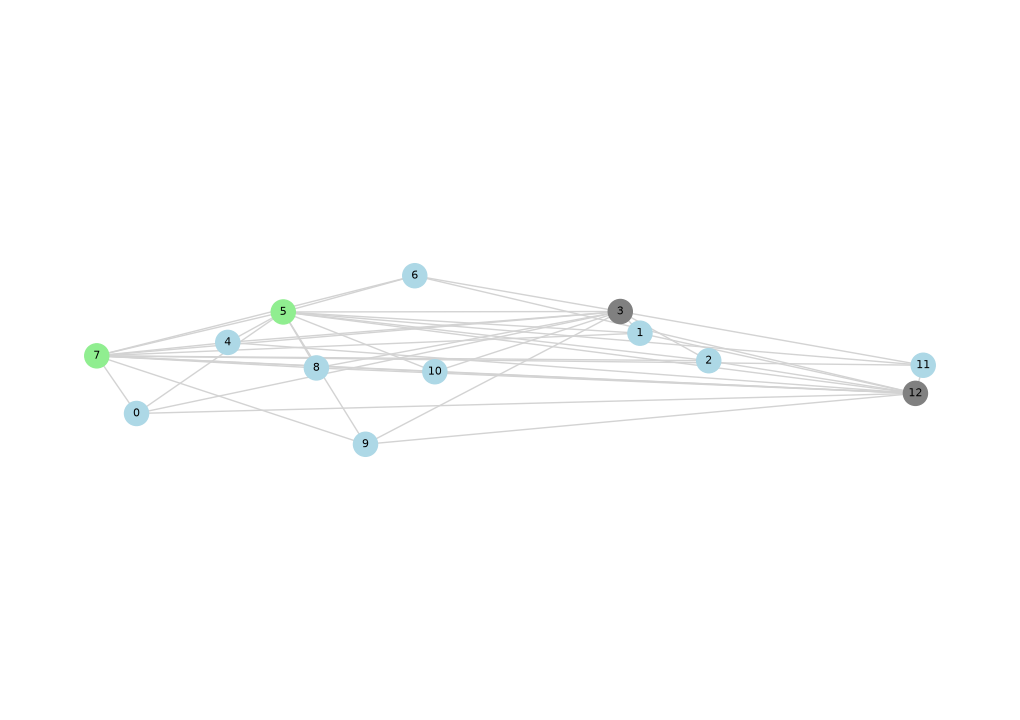

In [7]:
candidate_graph = planner_data.candidate_graph()
reports.draw_network_graph(candidate_graph)


## 6. Compute Real Edge Metrics

The metric profile comes from the TOML `[metrics]` section. `GraphPlanner.compute_edge_metrics(...)` calls the geo service for RF links and stores the metric for each candidate edge.


In [8]:
geo = AsyncGeoServicePool(
    base_url="http://planning-service:8080",
    user_prefix="rpl-real",
    pool_size=2,
    timeout=120,
)

edge_metrics = await planner_data.compute_edge_metrics(
    geo,
    manage_geo=True,
)

print("computed edge metrics:", len(edge_metrics))


APIResult(kind='json')
APIResult(kind='json')
computed edge metrics: 41


In [9]:
metric_table = reports.edge_table(planner_data, "metric")
metric_table


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,torre:d0:i0,tenis:d0:i0,rf,connectivity_0,torre,tenis,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
1,torre:d0:i0,praca_29:d0:i0,rf,connectivity_0,torre,praca_29,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
2,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
3,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
4,torre:d0:i0,shopping:d0:i0,rf,connectivity_0,torre,shopping,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
5,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
6,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
7,torre:d0:i0,deneka:d0:i0,rf,connectivity_0,torre,deneka,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
8,torre:d0:i0,copel:d0:i0,rf,connectivity_0,torre,copel,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000
9,torre:d0:i0,saturno:d0:i0,rf,connectivity_0,torre,saturno,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.000


## 7. Run RPL


In [10]:
planner_data.run_rpl()
planner_data.rpl_result_counts()


{'nodes': 12, 'edges': 11}

## 8. Inspect Results

`reports.node_table(planner_data, "result")` contains the selected parent and rank per RPL node.


In [11]:
result_df = reports.node_table(planner_data, "result")
result_df


,node_index,node_id,site_id,device_id,parent,parent_index,parent_site_id,connected,rpl_relay,rank,interface_can_relay,can_relay
0,0,copel:d0:i0,copel,copel:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False
1,1,tenis:d0:i0,tenis,tenis:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False
2,2,praca_29:d0:i0,praca_29,praca_29:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False
3,3,torre:d0:i0,torre,torre:d0,NaN,NaN,NaN,True,True,0.0,True,True
4,4,woodland:d0:i0,woodland,woodland:d0,saturno:d0:i0,7.0,saturno,False,False,2.0,False,False
5,5,deneka:d0:i0,deneka,deneka:d0,torre:d0:i0,3.0,torre,False,True,1.0,True,True
6,6,cemiterio:d0:i0,cemiterio,cemiterio:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False
7,7,saturno:d0:i0,saturno,saturno:d0,torre:d0:i0,3.0,torre,False,True,1.0,True,True
8,8,decatlon:d0:i0,decatlon,decatlon:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False
9,9,shopping:d0:i0,shopping,shopping:d0,torre:d0:i0,3.0,torre,False,False,1.0,False,False


In [12]:
summary_df = result_df.loc[
    ~result_df["connected"],
    ["node_index", "site_id", "parent_index", "parent_site_id", "rank"],
].sort_values("site_id")
summary_df


,node_index,site_id,parent_index,parent_site_id,rank
10,10,barigui,3.0,torre,1.0
6,6,cemiterio,3.0,torre,1.0
0,0,copel,3.0,torre,1.0
8,8,decatlon,3.0,torre,1.0
5,5,deneka,3.0,torre,1.0
11,11,guaira,3.0,torre,1.0
2,2,praca_29,3.0,torre,1.0
7,7,saturno,3.0,torre,1.0
9,9,shopping,3.0,torre,1.0
1,1,tenis,3.0,torre,1.0


In [13]:
reports.edge_table(planner_data, "result")


,src,dst,kind,rule,src_site,dst_site,src_tech,dst_tech,src_freq_mhz,dst_freq_mhz,src_mount_height_m,dst_mount_height_m,metric
0,copel:d0:i0,torre:d0:i0,rf,connectivity_0,copel,torre,rpl-demo,rpl-demo,900.0,900.0,7.0,100.0,1.0
1,tenis:d0:i0,torre:d0:i0,rf,connectivity_0,tenis,torre,rpl-demo,rpl-demo,900.0,900.0,7.0,100.0,1.0
2,praca_29:d0:i0,torre:d0:i0,rf,connectivity_0,praca_29,torre,rpl-demo,rpl-demo,900.0,900.0,7.0,100.0,1.0
3,torre:d0:i0,deneka:d0:i0,rf,connectivity_0,torre,deneka,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
4,torre:d0:i0,cemiterio:d0:i0,rf,connectivity_0,torre,cemiterio,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
5,torre:d0:i0,saturno:d0:i0,rf,connectivity_0,torre,saturno,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
6,torre:d0:i0,decatlon:d0:i0,rf,connectivity_0,torre,decatlon,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
7,torre:d0:i0,shopping:d0:i0,rf,connectivity_0,torre,shopping,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
8,torre:d0:i0,barigui:d0:i0,rf,connectivity_0,torre,barigui,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0
9,torre:d0:i0,guaira:d0:i0,rf,connectivity_0,torre,guaira,rpl-demo,rpl-demo,900.0,900.0,100.0,7.0,1.0


## 9. Plot Result Graph


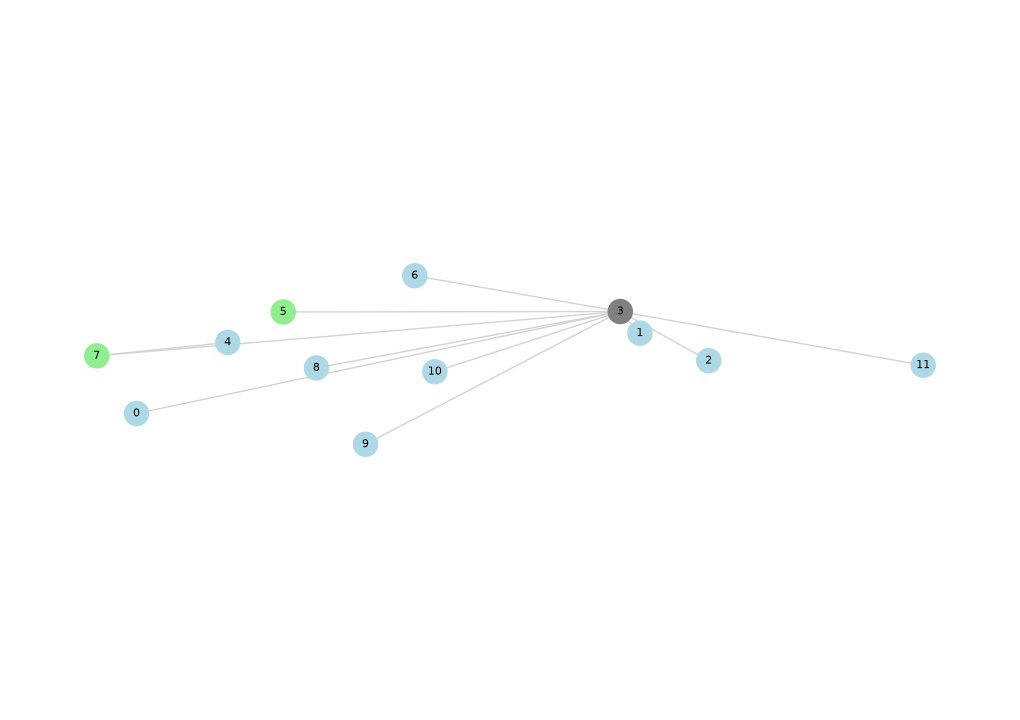

In [14]:
reports.draw_network_graph(planner_data.rpl.G_res)
